# 科学技術計算7回レポート


In [279]:
import numpy as np
# from numpy import , cos, sin

import scipy

from numpy.linalg import inv, norm, solve, det, matrix_rank, cond
from numpy import diag
rng = np.random.default_rng()

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams["savefig.bbox"] = "tight"

from typing import List, Optional, Union, Tuple, Dict


## 課題07-2

In [280]:
# 目的関数  n = m = 2
class Function2D():
    """
    2次元の非線形関数を表すクラス
    入力次元 n=2, 出力次元 m=2 または 3,
    """

    def __init__(self, n:int = 2, m:int = 2) -> None:
        """
        コンストラクタ,n と m を設定する．

        Args:
            n (int): 入力の次元（固定で 2）,
            m (int): 出力の次元（2 または 3）,
        """
        assert n == 2
        assert m == 2 or m == 3

        self.n = n
        self.m = m

    def do_callback(self, x, *callbacks):
        """
        コールバック関数を呼び出す．

        Args:
            x (np.ndarray): 入力 x
            callbacks (List[callable]): コールバック関数のリスト．
        """
        for callback in callbacks:
            callback(x)

    def __call__(self, x: np.ndarray, *args) -> np.ndarray:
        """
        非線形関数 f(x) を計算する．

        Args:
            x (np.ndarray): 入力 x（n次元ベクトル）
            args (callable): コールバック関数（任意）

        Returns:
            np.ndarray: 出力 f(x)（m次元ベクトル）
        """
        assert len(x) == self.n
        self.do_callback(x, *args)
        x_1, x_2 = x
        f_1 = np.exp(-np.exp(-x_1 - x_2)) - x_2 * (1 + x_1**2)
        f_2 = x_1 * np.cos(x_2) + x_2 * np.sin(x_1) - 0.5
        f_3 = x_2 * np.cos(x_1) + x_1 * np.sin(x_2) - 0.1
        if self.m == 2:
            fx = np.array([f_1, f_2])
        else:
            fx = np.array([f_1, f_2, f_3])
        return fx

    def jac(self, x: np.ndarray, *args) -> np.ndarray:
        """
        関数 f(x) のヤコビ行列 J(x) を計算する．

        Args:
            x (np.ndarray): 入力 x（n次元ベクトル）

        Returns:
            np.ndarray: ヤコビ行列 J(x)（shape: (m, n)）．
        """
        assert len(x) == self.n
        x_1, x_2 = x
        f_1_x_1 = np.exp(-np.exp(-x_1 - x_2)) * np.exp(-x_1 - x_2) - 2 * x_1 * x_2
        f_1_x_2 = np.exp(-np.exp(-x_1 - x_2)) * np.exp(-x_1 - x_2) - (1 + x_1**2)
        f_2_x_1 = np.cos(x_2) + x_2 * np.cos(x_1)
        f_2_x_2 = -x_1 * np.sin(x_2) + np.sin(x_1)
        f_3_x_1 = -x_2 * np.sin(x_1) + np.sin(x_2)
        f_3_x_2 = np.cos(x_1) + x_1 * np.cos(x_2)
        if self.m == 2:
            J = np.array([
                [f_1_x_1, f_1_x_2],
                [f_2_x_1, f_2_x_2],
            ])
        else:
            J = np.array([
                [f_1_x_1, f_1_x_2],
                [f_2_x_1, f_2_x_2],
                [f_3_x_1, f_3_x_2],
            ])
        return J



In [281]:
# 等高線の描画
def visualize_f(
        f: callable,
        ax: matplotlib.axis.Axis,
        x_min: float = -2.0,
        x_max: float = 2.0,
        y_min: float = -2.0,
        y_max: float = 2.0,
        levels: int | List[int] | None = None,
        plot_mse: bool = False,
        plot_index: List[int] = None,
        colors: List[str] = None,
        ) -> None:
    """目的関数 f を可視化する関数

    Args:
        f (callable, 'f(x: np.ndarray)'): 対象関数 f(x)
        ax (matplotlib.figure.Axis): matplotlib の axis オブジェクト
        x_min (float, optional): x 軸の最小値．デフォルトは -1.0．
        x_max (float, optional): x 軸の最大値．デフォルトは 1.0．
        y_min (float, optional): y 軸の最小値．デフォルトは -1.0．
        y_max (float, optional): y 軸の最大値．デフォルトは 1.0．
        levels (int, optional): 等高線の本数．デフォルトは 20．
        plot_mse (bool, optional): False の場合は各成分 f_i の等高線を描画，
                                   True の場合はベクトルノルム ||f||^2 を描画．
        plot_index (List(int), optional): 描画する関数のインデックス．None（デフォルト）の場合はすべてを描画．
        """

    # プロット範囲を設定
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # グリッドを作成
    XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
    # グリッド上の各点で関数 f を評価
    Z = np.array([f(x) for x in np.c_[XX.ravel(), YY.ravel()]])
    # reshape (hw, 1) --> (h, w, 2)
    Z = Z.reshape(*XX.shape, -1)  # グリッドの元の形状に再変形

    if plot_mse:  # ベクトルノルムの二乗 ||f||^2 を計算する場合
        Z = (Z**2).mean(axis=2)  # 各成分の二乗平均を計算 (h, w, 2) --> (h, w)
        Z = np.expand_dims(Z, 2)  # --> (h, w, 1)
        # 等高線のデフォルトの色を定義
        color_names = ["darkorange"] if colors is None else colors
        # 等高線のデフォルトを設定
        level=np.logspace(-1, 10) if levels is None else levels
    else:
        # 等高線のデフォルトの色を定義
        color_names = ["crimson", "indigo", "darkgreen", "orange"] if colors is None else colors
        # 等高線のデフォルトを設定
        level=20 if levels is None else levels

    # 等高線を描画
    for i in range(Z.shape[2]) if plot_index is None else plot_index:
        # 太線で 0 の等高線を描画（ゼロ交点を強調）
        ax.contour(XX, YY, Z[:, :, i], colors=color_names[i], levels=[0], linewidths=2)
        # 他の等高線を描画
        cs = ax.contour(XX, YY, Z[:, :, i], colors=color_names[i], levels=level, linewidths=0.5)
        # 等高線にラベルを付ける
        ax.clabel(cs, colors=color_names[i], fontsize="xx-small")


In [282]:
#解の反復の様子を記録
# 各反復ごとにxk,|f(xk)|を記録

class CacheXk(object):
    '''
    多次元の反復過程をキャッシュするクラス
    '''

    def __init__(
            self,
            f: callable,
            x0: np.ndarray,
            name: str
        ):
        """
        コンストラクタ

        Args:
            f (callable): 目的関数 f(x)
            x0 (np.ndarray): 初期値 x_0
            name (str): キャッシュの名前
        """
        assert hasattr(x0, "copy")
        self.__x_series = [x0.copy()]  # 解の履歴を記録
        self.__f_series = [norm(f(x0))]  # 関数値のノルムを記録
        self.x_label = "iterations k"  # x 軸ラベル
        self.f = f  # 目的関数を保存
        self.__name = str(name)  # 名前を保存

    def __call__(self, xk: np.ndarray) -> None:
        """
        コールバックとして現在の x_k を記録する

        Args:
            xk (np.ndarray): 現在の点 x_k
        """
        assert hasattr(xk, "copy")
        self.__x_series.append(xk.copy())
        self.__f_series.append(norm(self.f(xk)))

    def get_x(self) -> np.ndarray:
        """記録された x_k を取得"""
        return np.array(self.__x_series)

    def get_f(self) -> np.ndarray:
        """記録された $\|f(\boldsymbol{x}_k)\|$ を取得"""
        return np.array(self.__f_series)

    def get_name(self) -> str:
        """キャッシュの名前を取得"""
        return str(self.__name)



<>:46: SyntaxWarning: invalid escape sequence '\|'
<>:46: SyntaxWarning: invalid escape sequence '\|'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_26836\2789045024.py:46: SyntaxWarning: invalid escape sequence '\|'
  """記録された $\|f(\boldsymbol{x}_k)\|$ を取得"""


In [283]:
#CacheXkをプロットするクラス
class PlotCacheXk(object):
    """CacheXk クラスのデータをプロットするクラス"""

    def __init__(self, caches: List[CacheXk]) -> None:
        assert isinstance(caches, List), "should be a list of CacheXk"
        self.caches = caches
        self.f = caches[0].f
        self.x_label = "iterations k"
        self.colors = ['r', 'g', 'b', 'c', 'm', 'y']

    def plot_2d(
            self,
            plot_mse: bool = False,
            figsize:tuple = (5, 5)
        ) -> Dict[str, plt.figure]:
        """
        解の収束と関数値をプロットする

        Args:
            plot_mse (bool, optional): ノルムの二乗を描画するかどうか．デフォルトは False．
            figsize (tuple, optional): 図のサイズ．デフォルトは (5, 5)．

        Returns:
            Dict[str, plt.figure]: 各プロットの Figure オブジェクト
        """
        return {
            "convergence": self.plot_convergence(),
            "x_over_f": self.plot_x_over_f(plot_mse, figsize)
        }

    def plot_convergence(self) -> None:
        """
        各反復における $\boldsymbol{x}_k$ と $\|f(\boldsymbol{x}_k)\|$ をプロット

        Returns:
            plt.figure: プロットの fig オブジェクト
        """
        fig = plt.figure()
        axs = fig.subplots(2, sharex=True)

        # 各次元 x_k をプロット
        ax = axs[0]
        for cache, color in zip(self.caches, self.colors):
            ax.plot(cache.get_x()[:, 0], '.-', color=color,
                    label="x of " + cache.get_name())
            ax.plot(cache.get_x()[:, 1], '.--', color=color,
                    label="y of " + cache.get_name())
        ax.set_ylabel("$x_k$")
        ax.legend()

        # 関数値のノルムをプロット
        ax = axs[1]
        for cache, color in zip(self.caches, self.colors):
            ax.plot(cache.get_f(), '.-', color=color, label=cache.get_name())
        ax.set_ylabel("$\\| f(x_k) \\|$")
        ax.set_xlabel(self.x_label)
        ax.legend()

        plt.show()
        return fig

    def plot_x_over_f(self, plot_mse: bool, figsize: tuple) -> None:
        """
        軌跡と関数の等高線を描画

        Args:
            plot_mse (bool): ノルムの二乗を描画するかどうか
            figsize (tuple): 図のサイズ

        Returns:
            plt.figure: 軌跡プロットの Figure オブジェクト
        """
        fig = plt.figure(figsize=figsize)
        ax = fig.subplots()

        for cache, color in zip(self.caches, self.colors):
            x_series = cache.get_x()
            ax.scatter(
                x_series[0, 0],
                x_series[0, 1],
                color="w",
                s=50,
                edgecolors=color)
            ax.scatter(
                x_series[-1, 0],
                x_series[-1, 1],
                color=color,
                s=5,
                label=cache.get_name())
            ax.plot(
                x_series[:, 0],
                x_series[:, 1],
                marker='.',
                markersize=3,
                lw=1,
                color=color)

        visualize_f(self.f, ax)

        if plot_mse:
            visualize_f(self.f, ax, plot_mse=True)

        ax.legend()
        plt.show()

        return fig


<>:34: SyntaxWarning: invalid escape sequence '\|'
<>:34: SyntaxWarning: invalid escape sequence '\|'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_26836\1073594048.py:34: SyntaxWarning: invalid escape sequence '\|'
  各反復における $\boldsymbol{x}_k$ と $\|f(\boldsymbol{x}_k)\|$ をプロット


In [284]:
# chord法
def chord(
    f: callable,
    J: callable,
    x0: np.ndarray,
    maxiter: int = 100,
    callback: callable = None,
) -> np.ndarray:

    """chord法

    Args:
        f (callable): 目的関数 f(x)．ベクトル値関数．
        J (callable): ヤコビ行列 J(x)．
        x0 (np.ndarray): 初期値．
        maxiter (int, optional): 最大反復回数．デフォルトは 100．
        callback (callable, optional): 各反復で呼び出されるコールバック関数．デフォルトは None．

    Returns:
        np.ndarray: 解 \hat{x}
    """
    n = len(x0)
    assert len(f(x0)) == n
    assert J(x0).shape == (n, n)
    J = J(x0)

    x = x0.copy()
    for k in range(maxiter):
        f_x = f(x)  # 現在の関数ベクトルの計算

        # 解の更新方向dを計算
        d = solve(J, -f_x)

        x = x + d  # 解を更新

        if callback:
            callback(x)

        if np.isclose(norm(f_x), 0):
            return x

    return x


<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_26836\3590364655.py:20: SyntaxWarning: invalid escape sequence '\h'
  np.ndarray: 解 \hat{x}


x [0.35324662 0.60608173]
fx [ 4.02663836e-09 -2.11854773e-09]
x [0.35324662 0.60608173]
fx [ 2.14617379e-09 -1.62611202e-09]
x [0.35324662 0.60608174]
fx [-5.67704606e-09  3.81170728e-09]
x [0.35324662 0.60608174]
fx [ 1.39460310e-09 -5.69297243e-09]


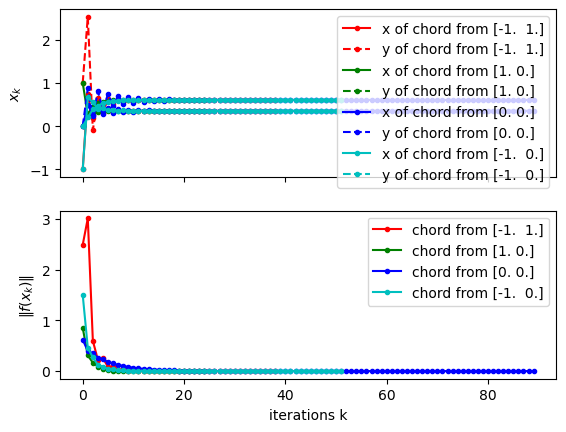

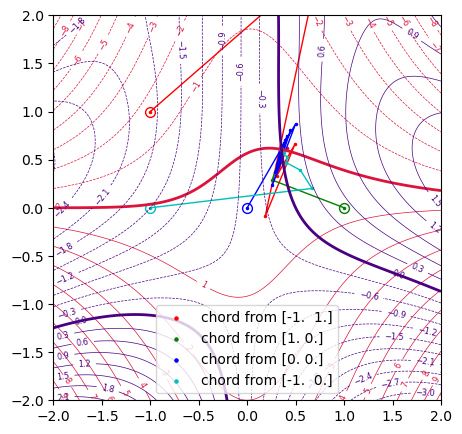

In [285]:
# 多次元のニュートン法を実行し解の収束の様子をプロットしたもの

f = Function2D()

callback_list = []

# 初期値
x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
    # np.array([1.5, 1.5]),
    # np.array([-1.5, -1.5]),
    # np.array([0.5, -1.5]),
    #コメントアウト3つは初期値変更で使用しました

]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"chord from {x0}")

    x = chord(
        f,      # 目的関数
        f.jac,  # ヤコビ行列
        x0,     # 初期値
        callback=cache_callback  # コールバック
    )
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d()
# figs = plot_cache.plot_2d(plot_mse=True)

## 課題07-4

In [ ]:
# LM法改良
def levenberg_marquardt_svd(
        f: callable,
        J: callable,
        x0: np.ndarray,
        lmd: float = 1.0,
        alpha: float = 0.5,
        gamma1: float = 0.8,
        gamma2: float = 2.0,
        maxiter: int = 100,
        callback: callable = None
) -> np.ndarray:
    """Levenberg-Marquardt 法

    Args:
        f (callable): 非線形方程式のベクトル値関数 f(x)
        J (callable): f(x) のヤコビ行列 J(x)
        x0 (np.ndarray): 初期値
        lmd (float, optional): 正則化パラメータ λ の初期値．デフォルトは 1.0
        alpha (float, optional): ステップサイズ．デフォルトは 0.5
        gamma1 (float, optional): λの減少率．デフォルトは 0.8
        gamma2 (float, optional): λの増加率．デフォルトは 2.0
        maxiter (int, optional): 最大反復回数．デフォルトは 100
        callback (callable, optional): 各反復ごとに呼び出されるコールバック関数．デフォルトは None

    Returns:
        np.ndarray: 解 \hat{x}
    """
    n = len(x0)
    m = len(f(x0))
    assert J(x0).shape == (m, n)
    
    x = x0.copy()
    
    for k in range(maxiter):
        J_x = J(x)  # ヤコビ行列 J(x)
        U, w, V_T = np.linalg.svd(J_x, full_matrices=False)

        W_plus = w / (w**2 + lmd)
        W_plus_mat = np.diag(W_plus)
        
        f_x = f(x)  # 関数値 f(x)

        # 解の更新方向dを計算更新式
        d = - V_T.T @ W_plus_mat @ U.T @ f_x
        x_next = x + alpha * d  # 解を更新

        if norm(f_x) > norm(f(x_next)):  # 目的関数値が減少する場合
            x = x_next  # 解を更新
            lmd *= gamma1  # λ を減少
        else:  # 目的関数値が減少しない場合
            lmd *= gamma2  # λ を増加

        if callback:
            callback(x)

        if np.isclose(norm(f_x), 0):
            return x

    return x


<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
C:\Users\sayuk\AppData\Local\Temp\ipykernel_26836\121588935.py:27: SyntaxWarning: invalid escape sequence '\h'
  np.ndarray: 解 \hat{x}


x [0.36212601 0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]
x [0.36212601 0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]
x [0.362126   0.23827601]
fx [ 0.30824088 -0.06369298  0.20829457]
x [0.36212601 0.23827601]
fx [ 0.30824088 -0.06369297  0.20829457]


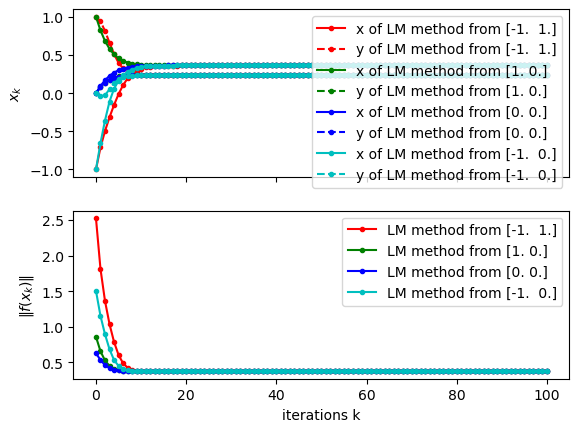

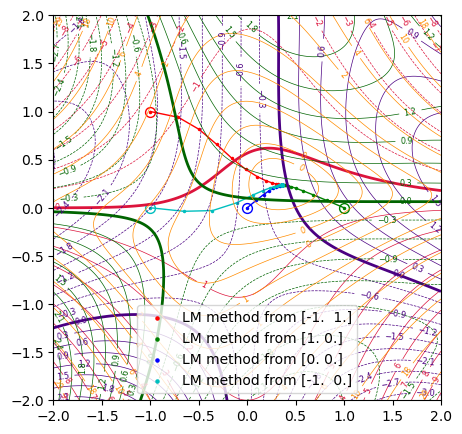

In [287]:
f = Function2D(m=3)

callback_list = []

x0_list = [
    np.array([-1.0, 1.0]),
    np.array([1.0, 0.0]),
    np.array([0.0, 0.0]),
    np.array([-1.0, 0.0]),
]
for x0 in x0_list:

    cache_callback = CacheXk(f, x0, f"LM method from {x0}")

    x = levenberg_marquardt_svd(
        f,      # 目的関数
        f.jac,  # ヤコビ行列
        x0,     # 初期値
        # alpha=1.0,  # ステップサイズ
        # lmd=1.0,    # λの初期値
        callback=cache_callback  # コールバック
    )
    print("x", x)
    print("fx", f(x))

    callback_list.append(cache_callback)

plot_cache = PlotCacheXk(callback_list)
figs = plot_cache.plot_2d(plot_mse=True)